# 평가자 일치도 분석

- 여러 LLM-as-Judge 모델 간 평가 결과의 일치 정도를 정량화할 수 있다
- Cohen's Kappa와 Fleiss' Kappa를 계산하고 해석할 수 있다
- 평가자 간 불일치 사례를 분석하여 평가 기준의 취약점을 파악할 수 있다
- 평가 신뢰도를 높이기 위한 전략을 설계할 수 있다

---

## 환경 설정

### (1) 환경변수 로드

In [ ]:
from dotenv import load_dotenv, find_dotenv

# 현재 폴더부터 상위 폴더로 .env 파일을 자동으로 탐색합니다
load_dotenv(find_dotenv())

True

### (2) 기본 라이브러리

In [ ]:
import os
import json
import itertools
from glob import glob
from pprint import pprint

import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# 한국어 폰트 설정 (macOS)
matplotlib.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

import warnings
warnings.filterwarnings("ignore")

### (3) Langfuse 핸들러 설정 (선택사항)

Langfuse 키가 없는 환경에서는 자동으로 건너뜁니다.

In [ ]:
try:
    from langfuse.langchain import CallbackHandler
    from langfuse import get_client

    langfuse_handler = CallbackHandler()
    langfuse_client = get_client()
    LANGFUSE_ENABLED = True
    print("Langfuse 설정 완료 ✓")
except Exception as e:
    langfuse_handler = None
    langfuse_client = None
    LANGFUSE_ENABLED = False
    print(f"Langfuse 비활성화 (키 없음 또는 연결 실패): {e}")

Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


Langfuse 설정 완료 ✓


### (4) 테스트 데이터 로드

In [ ]:
# 테스트 데이터셋 로드
df_qa_test = pd.read_excel("../data/testset.xlsx")

# ✏️ Judge 3개 × API 호출 비용/시간 절감을 위해 샘플 수 제한
MAX_SAMPLES = 15
df_qa_test = df_qa_test.head(MAX_SAMPLES).reset_index(drop=True)

print(f"테스트셋 로드 완료: {df_qa_test.shape[0]}개 문항 사용 (전체 49개 중 {MAX_SAMPLES}개)")
df_qa_test.head(3)

테스트셋 로드 완료: 15개 문항 사용 (전체 49개 중 15개)


,user_input,reference_contexts,reference,synthesizer_name
0,"Tesla, Inc.는 미국에서 어떤 역할을 하고 있으며, 이 회사의 주요 제품과 ...","['Tesla, Inc.는 미국의 다국적 자동차 및 청정 에너지 회사입니다. 이 회...","Tesla, Inc.는 미국의 다국적 자동차 및 청정 에너지 회사로, 전기 자동차(...",single_hop_specifc_query_synthesizer
1,Forbes Global 2000에서 테슬라 순위 뭐야?,['Tesla의 차량 생산은 2008년 Roadster로 시작하여 Model S (...,테슬라는 Forbes Global 2000에서 69위에 랭크되었습니다.,single_hop_specifc_query_synthesizer
2,Tesla는 언제 누가 만들었나?,"['Tesla는 내부 고발자 보복, 근로자 권리 침해, 안전 결함, 홍보 부족, M...","Tesla Motors, Inc.는 2003년 7월 1일에 Martin Eberha...",single_hop_specifc_query_synthesizer


### (5) ChromaDB 및 RAG 체인 구성

In [ ]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from ranx_k.tokenizers import KiwiTokenizer

# ChromaDB 로드
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
chroma_db = Chroma(
    collection_name="db_korean_cosine_metadata",
    embedding_function=embeddings,
    persist_directory="../chroma_db/",
)
chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 4})

# BM25 검색기 로드
def load_jsonlines(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

# JSONL이 이중 JSON 인코딩 (각 줄이 JSON 문자열 내부에 또 JSON)
raw_docs = load_jsonlines("../korean_docs_final.jsonl")
documents = [
    Document(
        page_content=json.loads(d)["page_content"],
        metadata=json.loads(d).get("metadata", {})
    )
    for d in raw_docs
]

kiwi_tokenizer = KiwiTokenizer(use_stopwords=False, pos_filter=[])
bm25_retriever = BM25Retriever.from_documents(
    documents, preprocess_func=kiwi_tokenizer.tokenize, k=4
)

# 하이브리드 검색기
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, chroma_retriever],
    weights=[0.5, 0.5],
)

# RAG 체인
def create_rag_chain(retriever, llm):
    template = """다음 컨텍스트를 바탕으로 질문에 답하세요.

[컨텍스트]
{context}

[질문]
{question}

[답변]
"""
    prompt = ChatPromptTemplate.from_template(template)
    def format_docs(docs):
        return "\n\n".join([d.page_content for d in docs])
    return (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
openai_rag_chain = create_rag_chain(hybrid_retriever, llm)

print(f"ChromaDB: {chroma_db._collection.count()}개 문서, RAG 체인 준비 완료")

Quantization is not supported for ArchType::neon. Fall back to non-quantized model.


ChromaDB: 39개 문서, RAG 체인 준비 완료


---

## 1. 평가자 정의

In [ ]:
from openevals.llm import create_llm_as_judge

# 공통 한국어 Correctness 평가 프롬프트
# choices=[0.0, 0.5, 1.0]으로 이산형 점수 사용 → Cohen's Kappa 계산에 적합
KOREAN_CORRECTNESS_PROMPT = """당신은 RAG 시스템의 답변 정확성을 평가하는 전문가입니다.

<질문>
{inputs}
</질문>

<생성된 답변>
{outputs}
</생성된 답변>

<참조 답변>
{reference_outputs}
</reference_outputs>

다음 기준에 따라 반드시 아래 점수 중 하나를 선택하세요:

- **1.0**: 생성된 답변이 참조 답변과 동일하거나 모든 핵심 내용을 포함하고 사실적으로 정확함
- **0.5**: 생성된 답변이 참조 답변의 일부 핵심 내용을 포함하지만 일부 누락되거나 부정확함  
- **0.0**: 생성된 답변이 참조 답변과 다르거나 사실적으로 부정확함

반드시 1.0, 0.5, 0.0 중 하나만 선택하세요.
"""

# 3개 Judge 모델 생성 (동일한 프롬프트 + 다른 모델)
judge_gpt_mini = create_llm_as_judge(
    prompt=KOREAN_CORRECTNESS_PROMPT,
    feedback_key="correctness",
    model="openai:gpt-4.1-mini",
    choices=[0.0, 0.5, 1.0],      # 이산형 선택지
)

judge_gpt_nano = create_llm_as_judge(
    prompt=KOREAN_CORRECTNESS_PROMPT,
    feedback_key="correctness",
    model="openai:gpt-4.1-nano",
    choices=[0.0, 0.5, 1.0],
)

judge_groq = create_llm_as_judge(
    prompt=KOREAN_CORRECTNESS_PROMPT,
    feedback_key="correctness",
    model="groq:llama-3.3-70b-versatile",
    choices=[0.0, 0.5, 1.0],
)

# Judge 딕셔너리 (이름 → judge 함수)
judges = {
    "GPT-4.1-mini": judge_gpt_mini,
    "GPT-4.1-nano": judge_gpt_nano,
    "Llama-3.3-70b (Groq)": judge_groq,
}

print("Judge 모델 초기화 완료")
for name in judges:
    print(f"  - {name}")

Judge 모델 초기화 완료
  - GPT-4.1-mini
  - GPT-4.1-nano
  - Llama-3.3-70b (Groq)


---

## 2. 테스트 데이터 평가 실행

각 Judge 모델로 testset 전체를 평가하고 점수를 수집합니다.

In [ ]:
import time

# 1단계: RAG 체인으로 전체 테스트셋 답변 생성
print("RAG 체인으로 답변 생성 중...")
test_records = []

for i, row in df_qa_test.iterrows():
    question = str(row.get("user_input", ""))
    reference = str(row.get("reference", ""))
    
    # RAG 체인 실행
    answer = openai_rag_chain.invoke(question)
    
    test_records.append({
        "idx": i,
        "question": question,
        "answer": answer,
        "reference": reference,
    })
    
    # 진행 상황 출력 (5개마다)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(df_qa_test)}개 완료...")

print(f"\n답변 생성 완료: {len(test_records)}개")

# 결과 데이터프레임 생성
df_answers = pd.DataFrame(test_records)
df_answers.head(3)

RAG 체인으로 답변 생성 중...


  5/15개 완료...


  10/15개 완료...


  15/15개 완료...

답변 생성 완료: 15개


,idx,question,answer,reference
0,0,"Tesla, Inc.는 미국에서 어떤 역할을 하고 있으며, 이 회사의 주요 제품과 ...","Tesla, Inc.는 미국의 다국적 자동차 및 청정 에너지 회사로서 전기 자동차(...","Tesla, Inc.는 미국의 다국적 자동차 및 청정 에너지 회사로, 전기 자동차(..."
1,1,Forbes Global 2000에서 테슬라 순위 뭐야?,Forbes Global 2000에서 테슬라는 69위에 랭크되었습니다.,테슬라는 Forbes Global 2000에서 69위에 랭크되었습니다.
2,2,Tesla는 언제 누가 만들었나?,"Tesla Motors, Inc.는 2003년 7월 1일에 Martin Eberha...","Tesla Motors, Inc.는 2003년 7월 1일에 Martin Eberha..."


In [ ]:
# 2단계: 각 Judge 모델로 평가 실행
print("Judge 모델로 평가 실행 중...")
judge_scores = {name: [] for name in judges}

for i, record in enumerate(test_records):
    for judge_name, judge_fn in judges.items():
        try:
            result = judge_fn(
                inputs=record["question"],
                outputs=record["answer"],
                reference_outputs=record["reference"],
            )
            score = result.get("score", 0.0)
            # score가 bool인 경우 float 변환
            if isinstance(score, bool):
                score = 1.0 if score else 0.0
            judge_scores[judge_name].append(float(score))
        except Exception as e:
            err_msg = str(e)[:120]
            if "RESOURCE_EXHAUSTED" in str(e) or "429" in str(e):
                print(f"  ⚠️ 쿼터 초과 [{judge_name}]: 일일 한도 초과 → 0.0으로 처리")
            else:
                print(f"  오류 [{judge_name}, idx={i}]: {err_msg}")
            judge_scores[judge_name].append(0.0)
    
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(test_records)}개 평가 완료...")

print(f"\n모든 Judge 평가 완료")

# Judge 점수를 데이터프레임에 추가
for judge_name, scores in judge_scores.items():
    df_answers[judge_name] = scores

df_answers.head()

Judge 모델로 평가 실행 중...


  오류 [GPT-4.1-nano, idx=0]: 'score'


  5/15개 평가 완료...


  10/15개 평가 완료...


  15/15개 평가 완료...

모든 Judge 평가 완료


,idx,question,answer,reference,GPT-4.1-mini,GPT-4.1-nano,Llama-3.3-70b (Groq)
0,0,"Tesla, Inc.는 미국에서 어떤 역할을 하고 있으며, 이 회사의 주요 제품과 ...","Tesla, Inc.는 미국의 다국적 자동차 및 청정 에너지 회사로서 전기 자동차(...","Tesla, Inc.는 미국의 다국적 자동차 및 청정 에너지 회사로, 전기 자동차(...",1.0,0.0,1.0
1,1,Forbes Global 2000에서 테슬라 순위 뭐야?,Forbes Global 2000에서 테슬라는 69위에 랭크되었습니다.,테슬라는 Forbes Global 2000에서 69위에 랭크되었습니다.,1.0,1.0,1.0
2,2,Tesla는 언제 누가 만들었나?,"Tesla Motors, Inc.는 2003년 7월 1일에 Martin Eberha...","Tesla Motors, Inc.는 2003년 7월 1일에 Martin Eberha...",1.0,1.0,0.5
3,3,Larry Page는 전기차 시장에서 어떤 역할을 했나요?,Larry Page는 Tesla의 초기 후속 자금 조달에 투자자로 참여하여 전기차 ...,Larry Page는 전기차 시장에서 Tesla의 후속 자금 조달에 투자한 기업가 ...,1.0,0.5,0.5
4,4,Toyota와 Tesla의 관계는 무엇인가요?,Toyota와 Tesla는 과거 파트너 관계에 있었습니다. Tesla는 2010년 ...,"2010년 5월, Tesla는 캘리포니아 주 프리몬트의 NUMMI 공장을 Toyot...",1.0,1.0,0.5


---

## 3. Cohen's Kappa 계산

모든 Judge 쌍에 대해 Cohen's Kappa를 계산합니다.

In [ ]:
from sklearn.metrics import cohen_kappa_score

judge_names = list(judges.keys())

# 모든 Judge 쌍에 대해 Cohen's Kappa 계산
kappa_matrix = pd.DataFrame(
    np.ones((len(judge_names), len(judge_names))),  # 대각선 = 1.0 (자기 자신과 일치)
    index=judge_names,
    columns=judge_names,
)

kappa_results = {}

for judge_a, judge_b in itertools.combinations(judge_names, 2):
    scores_a = df_answers[judge_a].values
    scores_b = df_answers[judge_b].values
    
    try:
        # 이산형 범주로 변환 (0.0, 0.5, 1.0 → 문자열 레이블)
        labels_a = [str(s) for s in scores_a]
        labels_b = [str(s) for s in scores_b]
        
        kappa = cohen_kappa_score(labels_a, labels_b)
        if np.isnan(kappa):  # 두 Judge 점수가 완전히 동일한 경우 (0/0)
            kappa = 1.0
    except Exception as e:
        print(f"  계산 오류 ({judge_a} vs {judge_b}): {e}")
        kappa = float("nan")
    
    kappa_matrix.loc[judge_a, judge_b] = kappa
    kappa_matrix.loc[judge_b, judge_a] = kappa  # 대칭 행렬
    kappa_results[f"{judge_a} vs {judge_b}"] = kappa
    
    # Kappa 해석
    def interpret_kappa(k):
        if np.isnan(k): return "완전 동일 (1.0으로 처리)"
        if k < 0:    return "일치 없음"
        elif k < 0.20: return "매우 낮음"
        elif k < 0.40: return "낮음"
        elif k < 0.60: return "보통"
        elif k < 0.80: return "높음"
        else:          return "거의 완벽"
    
    print(f"  {judge_a} vs {judge_b}: κ = {kappa:.4f} ({interpret_kappa(kappa)})")

print(f"\nCohen's Kappa 행렬:")
print(kappa_matrix.round(4))

  GPT-4.1-mini vs GPT-4.1-nano: κ = -0.0714 (일치 없음)
  GPT-4.1-mini vs Llama-3.3-70b (Groq): κ = 0.1964 (매우 낮음)
  GPT-4.1-nano vs Llama-3.3-70b (Groq): κ = 0.0789 (매우 낮음)

Cohen's Kappa 행렬:
                      GPT-4.1-mini  GPT-4.1-nano  Llama-3.3-70b (Groq)
GPT-4.1-mini                1.0000       -0.0714                0.1964
GPT-4.1-nano               -0.0714        1.0000                0.0789
Llama-3.3-70b (Groq)        0.1964        0.0789                1.0000


---

## 4. Fleiss' Kappa 계산

3명 이상의 평가자 간 일치도를 동시에 측정합니다. Cohen's Kappa의 일반화 버전입니다.

In [ ]:
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

# 평가 행렬 구성 (각 행: 하나의 샘플, 각 열: judge 점수)
# aggregate_raters는 평가자들의 범주형 레이블 행렬을 받아 집계합니다
ratings_matrix = df_answers[judge_names].values  # shape: (n_samples, n_judges)

# statsmodels aggregate_raters: 점수를 범주 빈도 행렬로 변환
# 점수를 정수 범주로 매핑 (0.0→0, 0.5→1, 1.0→2)
score_map = {0.0: 0, 0.5: 1, 1.0: 2}
int_ratings = np.vectorize(lambda x: score_map.get(x, 0))(ratings_matrix)

# aggregate_raters로 범주 빈도 행렬 생성
table, categories = aggregate_raters(int_ratings)

# Fleiss' Kappa 계산
fleiss_k = fleiss_kappa(table)

print(f"Fleiss' Kappa (3개 Judge 전체): κ = {fleiss_k:.4f}")
print(f"해석: {interpret_kappa(fleiss_k)}")

# categories: aggregate_raters가 반환한 실제 등장 범주 목록
label_map = {0: "0.0점", 1: "0.5점", 2: "1.0점"}
col_names = [label_map.get(cat, str(cat)) for cat in categories]
print("\n=== 범주 빈도 테이블 (처음 5행) ===")
print(pd.DataFrame(table[:5], columns=col_names))

Fleiss' Kappa (3개 Judge 전체): κ = 0.0296
해석: 매우 낮음

=== 범주 빈도 테이블 (처음 5행) ===
   0.0점  0.5점  1.0점
0     1     0     2
1     0     0     3
2     0     1     2
3     0     2     1
4     0     1     2


---

## 5. 결과 분석 및 시각화

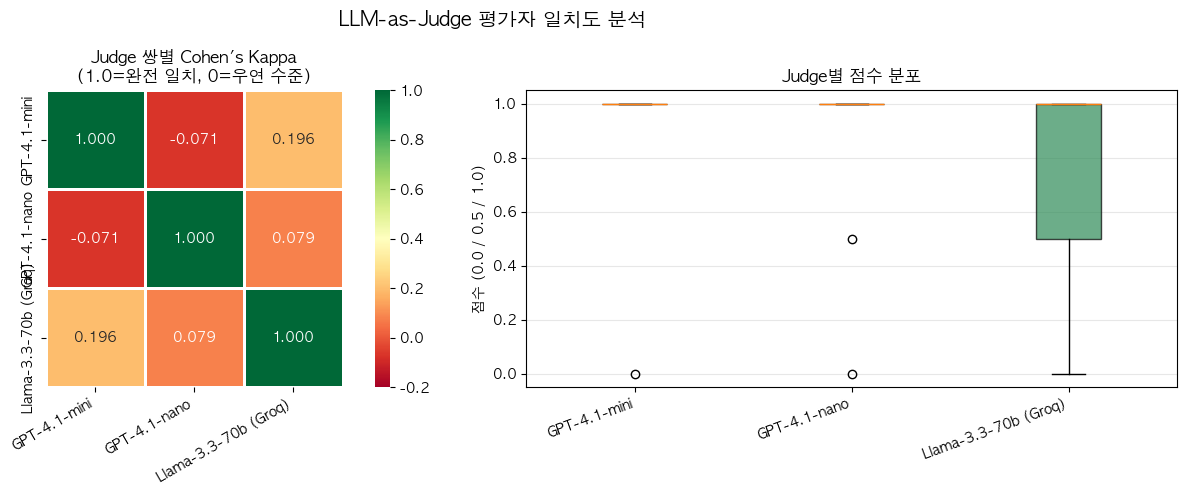

In [ ]:
# 1) Cohen's Kappa 히트맵 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kappa 행렬 히트맵
mask = np.eye(len(judge_names), dtype=bool)  # 대각선 마스크
sns.heatmap(
    kappa_matrix.astype(float),
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=-0.2,
    vmax=1.0,
    center=0.4,
    ax=axes[0],
    linewidths=1,
    square=True,
)
axes[0].set_title("Judge 쌍별 Cohen's Kappa\n(1.0=완전 일치, 0=우연 수준)", fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

# Judge별 점수 분포 박스플롯
score_data = [df_answers[name].values for name in judge_names]
bp = axes[1].boxplot(score_data, labels=judge_names, patch_artist=True)
colors = ["steelblue", "darkorange", "seagreen"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Judge별 점수 분포", fontsize=12)
axes[1].set_ylabel("점수 (0.0 / 0.5 / 1.0)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("LLM-as-Judge 평가자 일치도 분석", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## 6. 불일치 사례 분석

Judge 간 점수 차이가 큰 사례를 추출하여 불일치 원인을 분석합니다.

In [ ]:
# 불일치 점수 계산 (Judge 간 표준편차)
df_answers["score_std"] = df_answers[judge_names].std(axis=1)
df_answers["score_range"] = df_answers[judge_names].max(axis=1) - df_answers[judge_names].min(axis=1)

# 불일치가 큰 상위 5개 사례 추출
high_disagreement = df_answers.nlargest(5, "score_range")[
    ["question", "answer", "reference"] + judge_names + ["score_std", "score_range"]
]

print("=== 평가자 간 불일치가 큰 사례 (상위 5개) ===\n")
for i, row in high_disagreement.iterrows():
    print(f"[사례 {i+1}]")
    print(f"  질문: {str(row['question'])[:80]}...")
    print(f"  답변: {str(row['answer'])[:80]}...")
    print(f"  참조: {str(row['reference'])[:80]}...")
    for judge_name in judge_names:
        print(f"  {judge_name}: {row[judge_name]:.1f}")
    print(f"  점수 범위: {row['score_range']:.1f} | 표준편차: {row['score_std']:.3f}")
    print()

=== 평가자 간 불일치가 큰 사례 (상위 5개) ===

[사례 1]
  질문: Tesla, Inc.는 미국에서 어떤 역할을 하고 있으며, 이 회사의 주요 제품과 서비스는 무엇인가요?...
  답변: Tesla, Inc.는 미국의 다국적 자동차 및 청정 에너지 회사로서 전기 자동차(BEV), 고정형 배터리 에너지 저장 장치, 태양 전지판, 태...
  참조: Tesla, Inc.는 미국의 다국적 자동차 및 청정 에너지 회사로, 전기 자동차(BEV), 고정형 배터리 에너지 저장 장치, 태양 전지판, 태...
  GPT-4.1-mini: 1.0
  GPT-4.1-nano: 0.0
  Llama-3.3-70b (Groq): 1.0
  점수 범위: 1.0 | 표준편차: 0.577

[사례 6]
  질문: Tesla의 Model 3에 대한 정보를 어디서 찾을 수 있나요?...
  답변: Tesla의 Model 3에 대한 정보는 다음 문단과 표에서 찾을 수 있습니다.

- 문단:  
  "Model 3: 패스트백 차체 스타일과 듀...
  참조: 제공된 문맥에는 Tesla의 Model 3에 대한 정보가 포함되어 있지 않습니다....
  GPT-4.1-mini: 0.0
  GPT-4.1-nano: 1.0
  Llama-3.3-70b (Groq): 0.0
  점수 범위: 1.0 | 표준편차: 0.577

[사례 3]
  질문: Tesla는 언제 누가 만들었나?...
  답변: Tesla Motors, Inc.는 2003년 7월 1일에 Martin Eberhard와 Marc Tarpenning에 의해 설립되었습니다....
  참조: Tesla Motors, Inc.는 2003년 7월 1일에 Martin Eberhard와 Marc Tarpenning에 의해 설립되었으며, 각각...
  GPT-4.1-mini: 1.0
  GPT-4.1-nano: 1.0
  Llama-3.3-70b (Groq): 0.5
  점수 범위: 0.5 | 표준편차: 0.289

[사례 4]
  질문: L

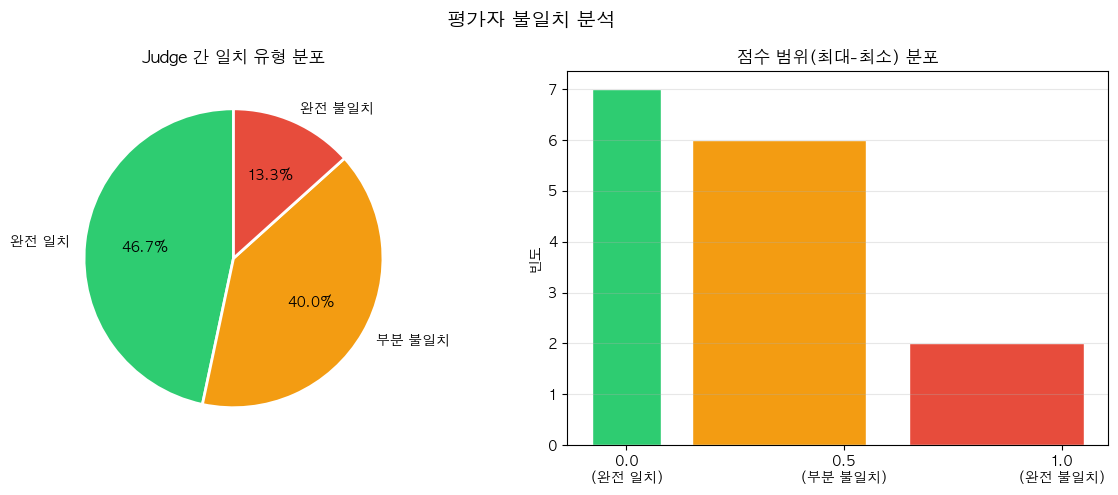


일치 유형별 빈도:
agreement_type
완전 일치     7
부분 불일치    6
완전 불일치    2
Name: count, dtype: int64


In [ ]:
# 불일치 유형별 분류
# 완전 일치: 모든 Judge가 동일한 점수
# 부분 불일치: 일부 Judge만 다름
# 완전 불일치: 최대-최소 차이가 1.0 이상

df_answers["agreement_type"] = df_answers["score_range"].apply(
    lambda r: "완전 일치" if r == 0.0 else ("부분 불일치" if r <= 0.5 else "완전 불일치")
)

agreement_counts = df_answers["agreement_type"].value_counts()

# 파이 차트
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 불일치 유형 파이 차트
colors_pie = ["#2ecc71", "#f39c12", "#e74c3c"]
axes[0].pie(
    agreement_counts.values,
    labels=agreement_counts.index,
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Judge 간 일치 유형 분포", fontsize=12)

# 점수 범위 분포
bar_colors = ["#2ecc71", "#f39c12", "#e74c3c"]
_, _, patches = axes[1].hist(
    df_answers["score_range"], bins=[-0.1, 0.1, 0.6, 1.1],
    edgecolor="white", rwidth=0.8
)
for patch, col in zip(patches, bar_colors):
    patch.set_facecolor(col)
axes[1].set_xticks([0, 0.5, 1.0])
axes[1].set_xticklabels(["0.0\n(완전 일치)", "0.5\n(부분 불일치)", "1.0\n(완전 불일치)"])
axes[1].set_title("점수 범위(최대-최소) 분포", fontsize=12)
axes[1].set_ylabel("빈도")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("평가자 불일치 분석", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n일치 유형별 빈도:\n{agreement_counts}")